# Logistic regression

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Imputador
from sklearn.impute import KNNImputer
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [4]:
df = pd.read_csv("../data/raw/winequality-red.csv", sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Análisis descriptivo 

In [5]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [6]:
df.shape

(1599, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
df.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [9]:
df.duplicated().sum()

np.int64(240)

### No hay duplicados pero nos aseguramos de borrarlos

In [10]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [11]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [12]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

#### No hay valores nulos

In [13]:
df['quality']

0       5
1       5
2       5
3       6
5       5
       ..
1593    6
1594    5
1595    6
1597    5
1598    6
Name: quality, Length: 1359, dtype: int64

### Limpieza de datos: Eliminar información irrelevante

In [23]:
corr_quality = df.corr()['quality'].drop('quality').abs().sort_values(ascending=False)
corr_quality

alcohol                 0.480343
volatile acidity        0.395214
sulphates               0.248835
citric acid             0.228057
density                 0.184252
total sulfur dioxide    0.177855
chlorides               0.130988
fixed acidity           0.119024
pH                      0.055245
free sulfur dioxide     0.050463
residual sugar          0.013640
Name: quality, dtype: float64

#### No eliminamos ninguna variable porque pueden tener cierta influencia en la variable objetivo

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


## Análisis de variables:

### Variables univariante: variables númericas

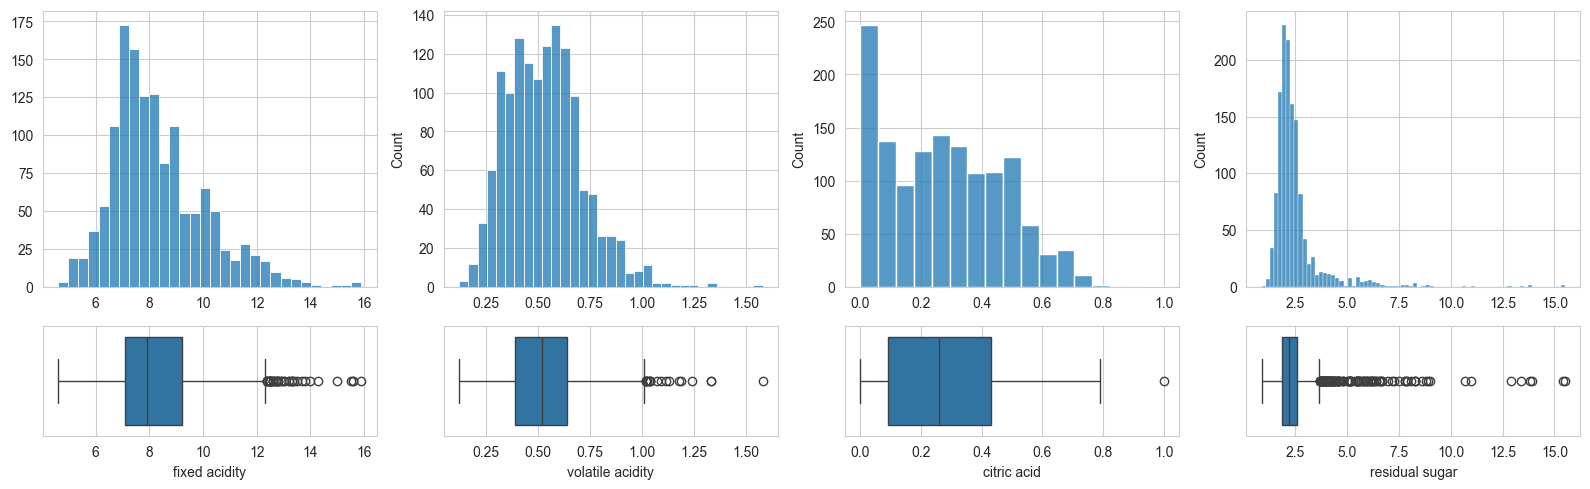

In [20]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="fixed acidity").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="fixed acidity")
sns.histplot(ax=axis[0, 1], data=df, x="volatile acidity").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="volatile acidity")
sns.histplot(ax=axis[0, 2], data=df, x="citric acid").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="citric acid")
sns.histplot(ax=axis[0, 3], data=df, x="residual sugar").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="residual sugar")
plt.tight_layout()
plt.show()

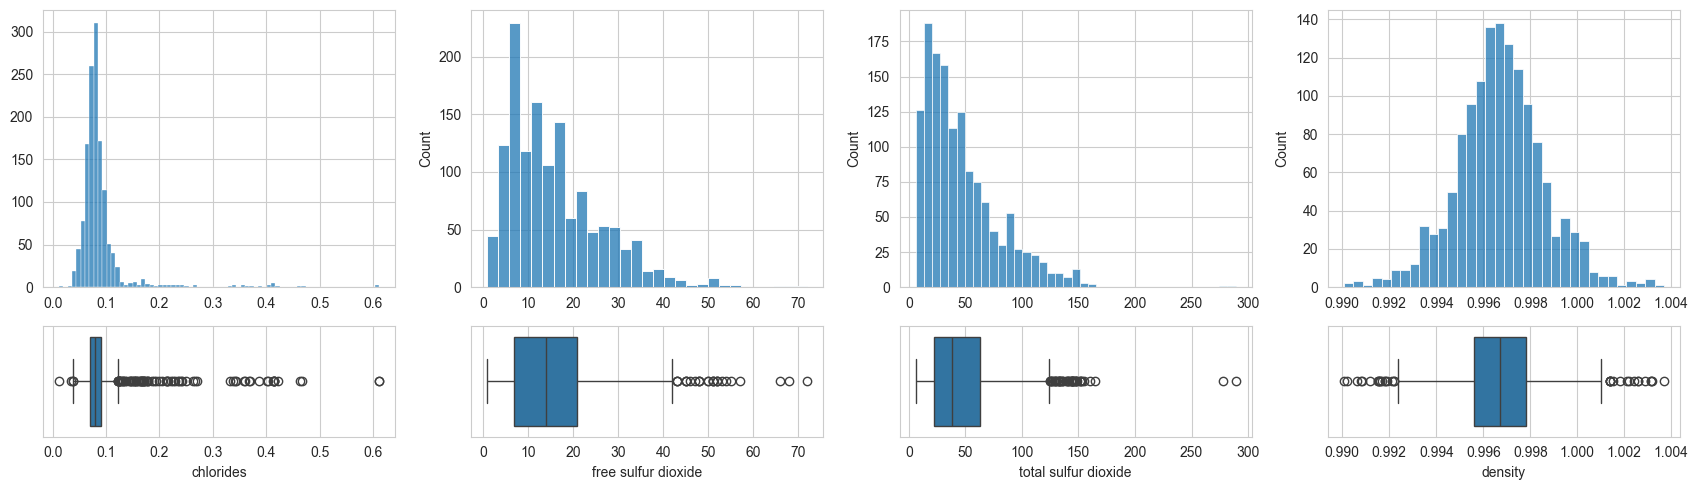

In [18]:
fig, axis = plt.subplots(2, 4, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="chlorides").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="chlorides")
sns.histplot(ax=axis[0, 1], data=df, x="free sulfur dioxide").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="free sulfur dioxide")
sns.histplot(ax=axis[0, 2], data=df, x="total sulfur dioxide").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="total sulfur dioxide")
sns.histplot(ax=axis[0, 3], data=df, x="density").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="density")

plt.tight_layout()
plt.show()

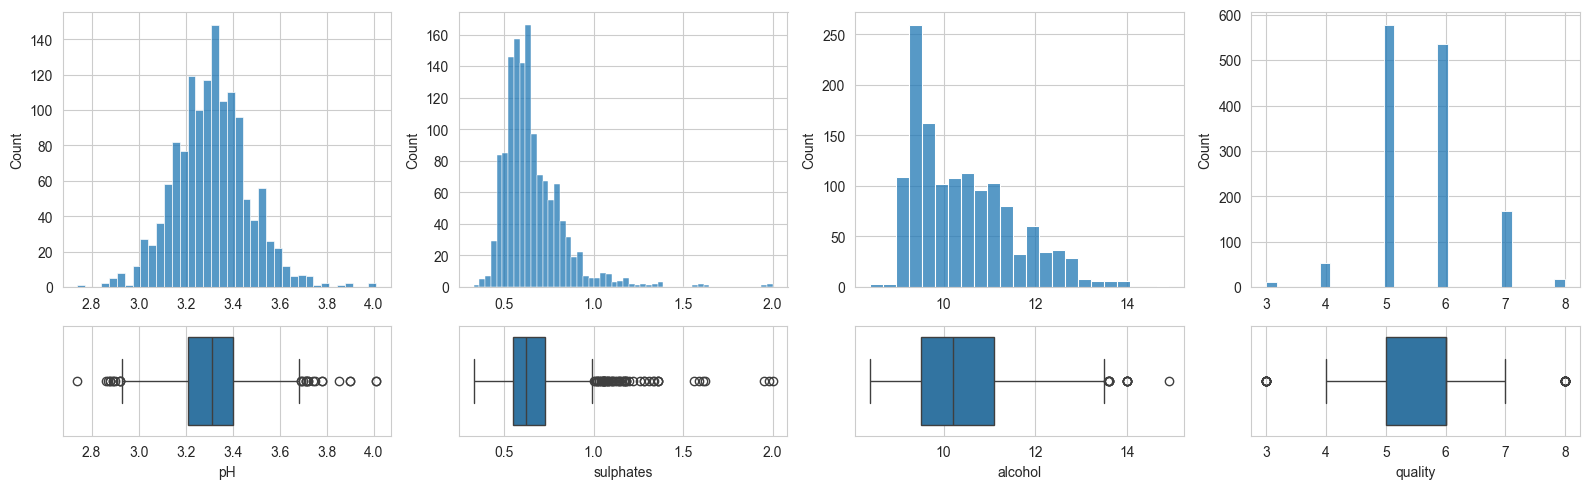

In [19]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="pH").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="pH")
sns.histplot(ax=axis[0, 1], data=df, x="sulphates").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="sulphates")
sns.histplot(ax=axis[0, 2], data=df, x="alcohol").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="alcohol")
sns.histplot(ax=axis[0, 3], data=df, x="quality").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="quality")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.
> - La variables siguen una distribución normalizada un poco sesgada hacia la izquierda

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

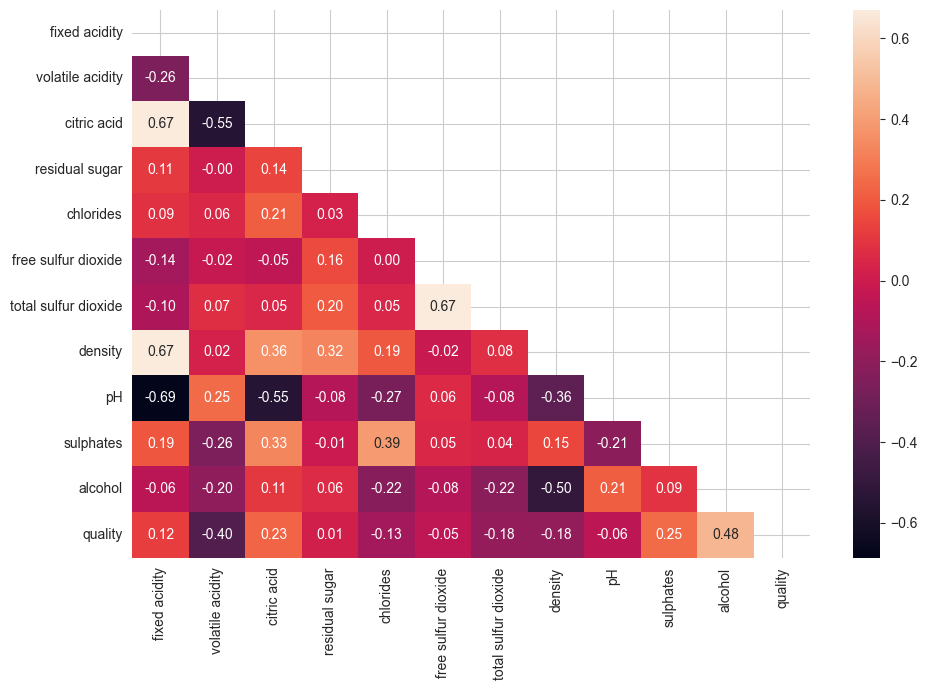

In [21]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:

Parece que todas las variables estan relacionadas de forma directa e indirecta, 'quality' se relaciona con 'volatile acidity' que a su vez se relaciona con 'citric acid', 'citric acid' se relaciona con 'fixed acidity' que se relaciona fuertemente con 'density' y 'ph'

### Correlaciones con la variable objetivo:

### Análisis de variables multivariante: númerico-númerico

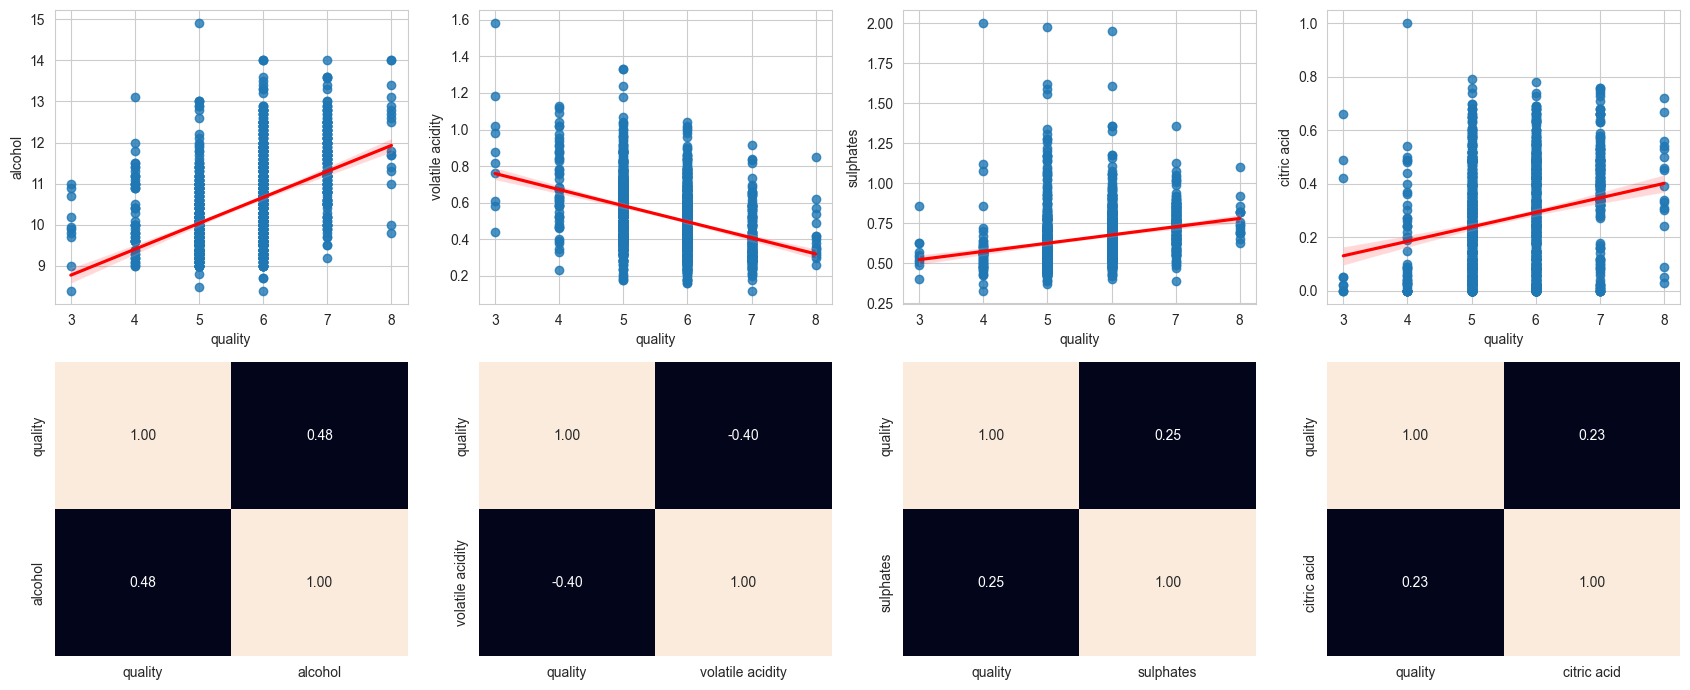

In [29]:
corr_quality_alcohol = df[["quality", "alcohol"]].corr()
corr_quality_volatile = df[["quality", "volatile acidity"]].corr()
corr_quality_sulphates = df[["quality", "sulphates"]].corr()
corr_quality_citric = df[["quality", "citric acid"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="quality", y="alcohol", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_quality_alcohol, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="quality", y="volatile acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_quality_volatile, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="quality", y="sulphates", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_quality_sulphates, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="quality", y="citric acid", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_quality_citric, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

In [26]:
corr_quality

alcohol                 0.480343
volatile acidity        0.395214
sulphates               0.248835
citric acid             0.228057
density                 0.184252
total sulfur dioxide    0.177855
chlorides               0.130988
fixed acidity           0.119024
pH                      0.055245
free sulfur dioxide     0.050463
residual sugar          0.013640
Name: quality, dtype: float64

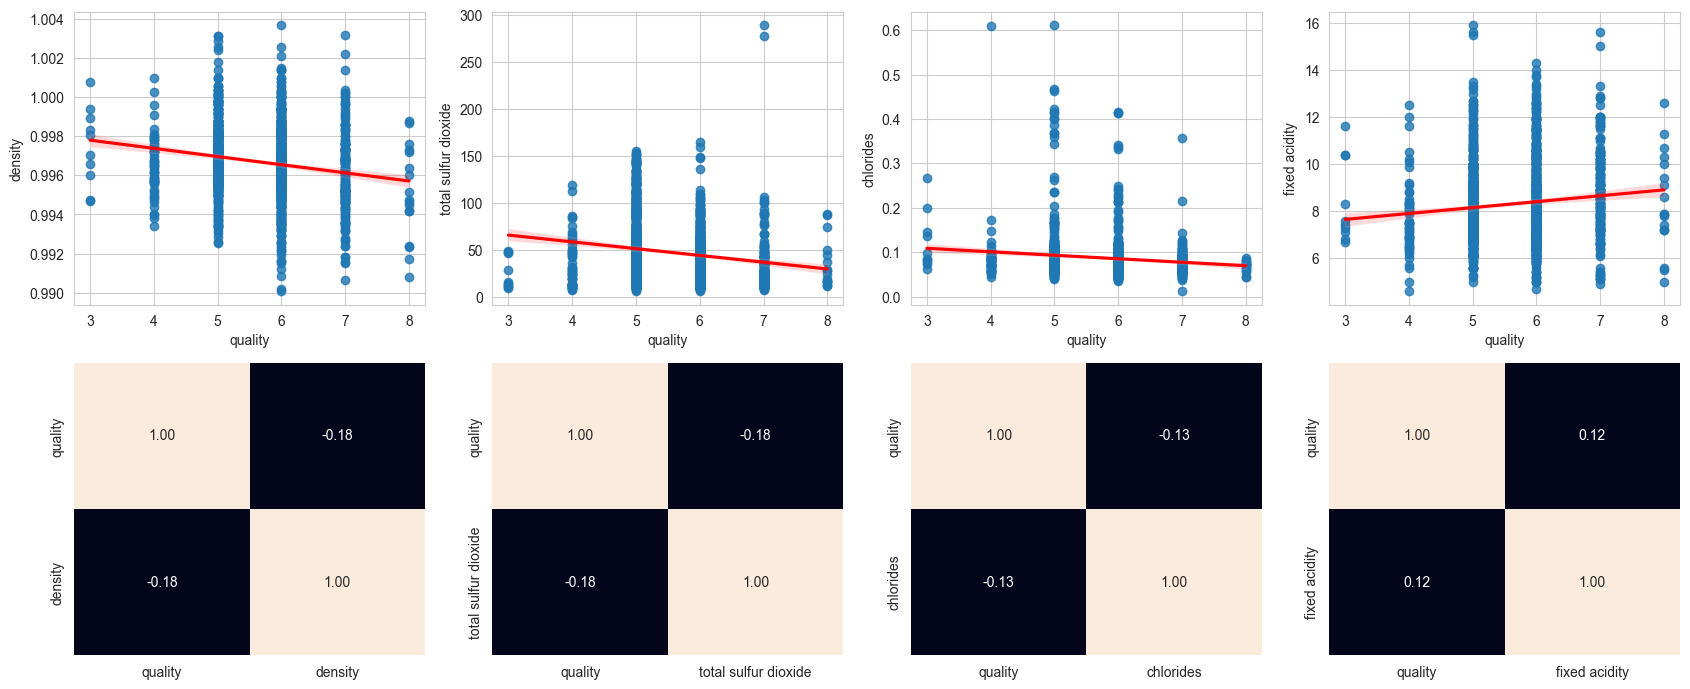

In [30]:
corr_quality_density = df[["quality", "density"]].corr()
corr_quality_sulfur = df[["quality", "total sulfur dioxide"]].corr()
corr_quality_chlorides = df[["quality", "chlorides"]].corr()
corr_quality_fixed = df[["quality", "fixed acidity"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="quality", y="density", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_quality_density, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="quality", y="total sulfur dioxide", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_quality_sulfur, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="quality", y="chlorides", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_quality_chlorides, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="quality", y="fixed acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_quality_fixed, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

> - Podemos decir que hay linealidad entre las variables más relacionadas con 'Outcome'


Parece que todas las variables estan relacionadas de forma directa e indirecta, 'quality' se relaciona con 'volatile acidity' que a su vez se relaciona con 'citric acid', 'citric acid' se relaciona con 'fixed acidity' que se relaciona fuertemente con 'density' y 'ph'. Procedemos a su estudio

### Otras correlaciones interesantes entre variables:

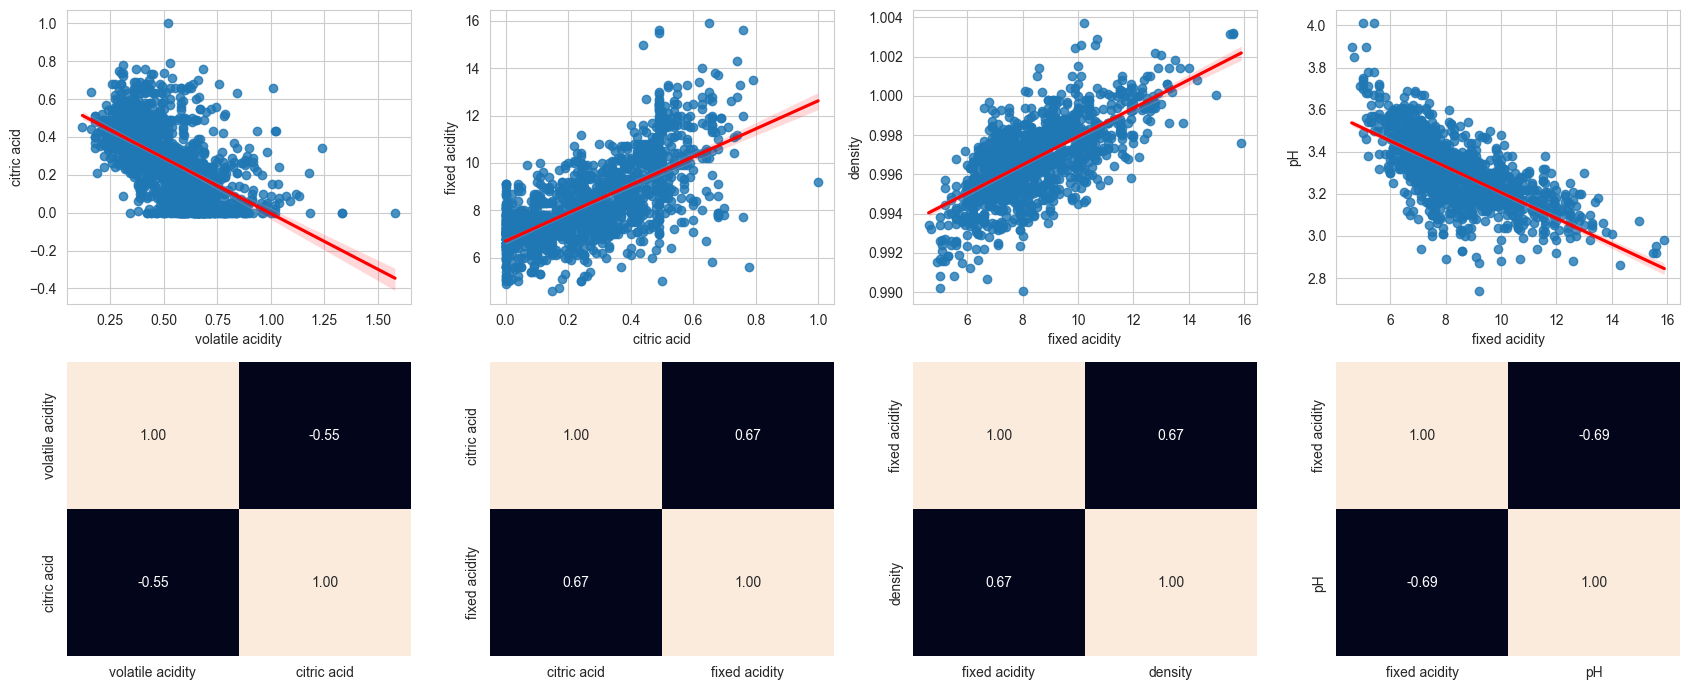

In [32]:
corr_volatile_citric = df[["volatile acidity", "citric acid"]].corr()
corr_citric_fixed = df[["citric acid", "fixed acidity"]].corr()
corr_fixed_density = df[["fixed acidity", "density"]].corr()
corr_fixed_ph = df[["fixed acidity", "pH"]].corr()
fig, axis = plt.subplots(2, 4, figsize=(17, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="volatile acidity", y="citric acid", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_volatile_citric, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="citric acid", y="fixed acidity", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_citric_fixed, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="fixed acidity", y="density", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_fixed_density, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,3], data=df, x="fixed acidity", y="pH", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,3], data=corr_fixed_ph, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

#### Hay una fuerte correlación y linealidad entre estas variables que a su vez se relacionan con otras y así por todo el conjunto de datos. Podemos decir que cada componente influye en la calidad del producto

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


#### Visualización

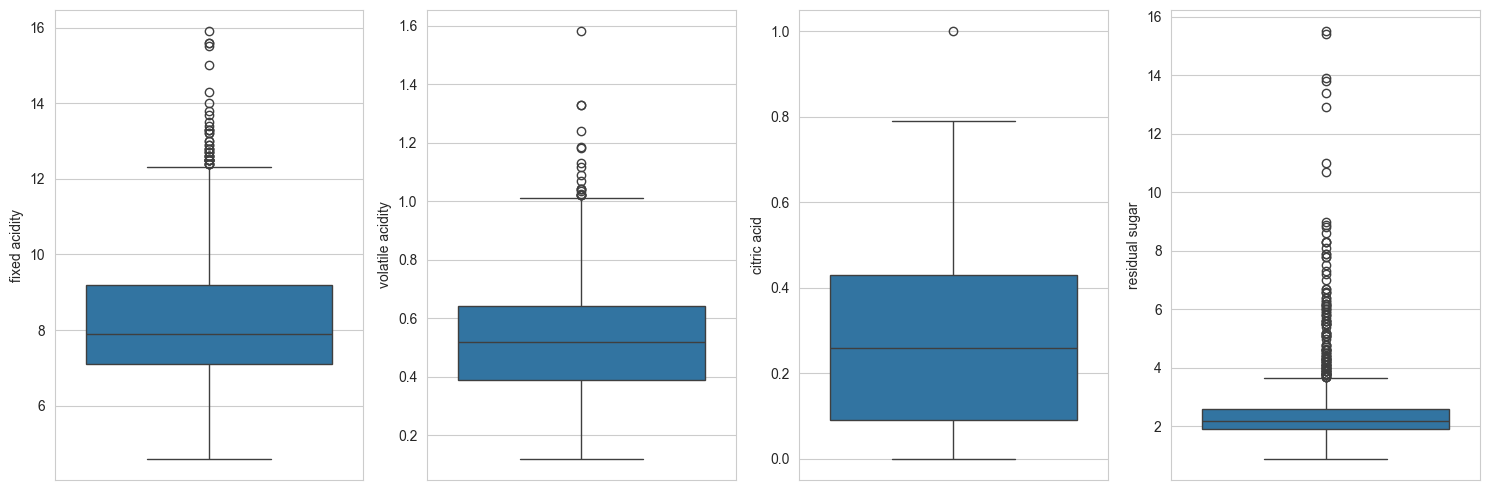

In [35]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="fixed acidity")
sns.boxplot(ax=axis[1], data=df, y="volatile acidity")
sns.boxplot(ax=axis[2], data=df, y="citric acid")
sns.boxplot(ax=axis[3], data=df, y="residual sugar")
plt.tight_layout()
plt.show()

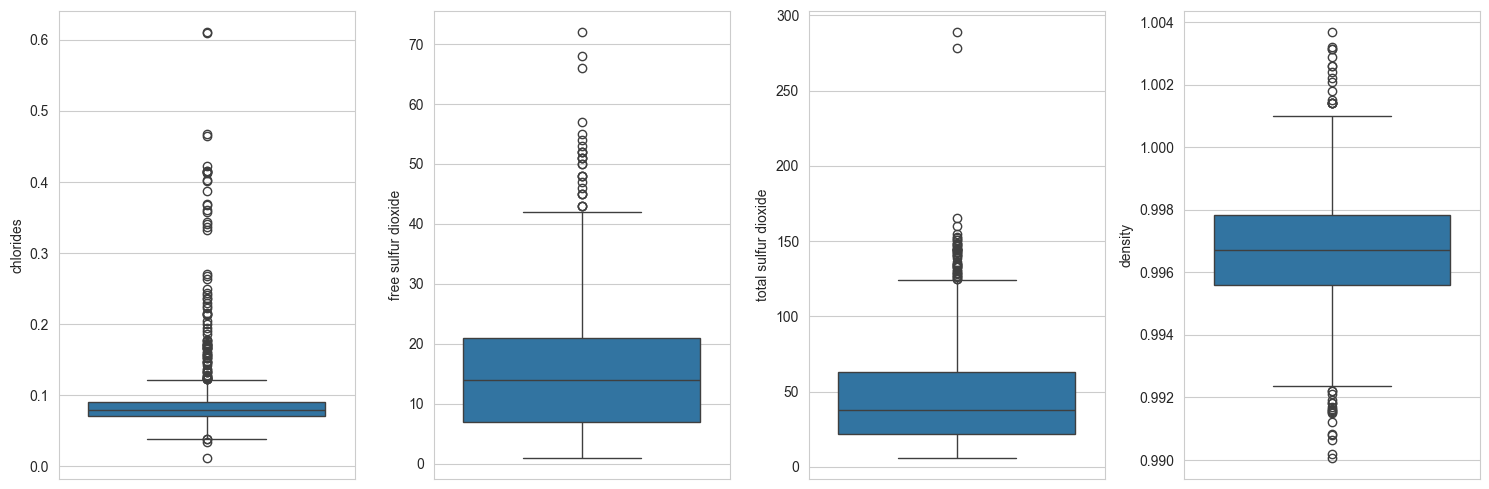

In [36]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="chlorides")
sns.boxplot(ax=axis[1], data=df, y="free sulfur dioxide")
sns.boxplot(ax=axis[2], data=df, y="total sulfur dioxide")
sns.boxplot(ax=axis[3], data=df, y="density")
plt.tight_layout()
plt.show()

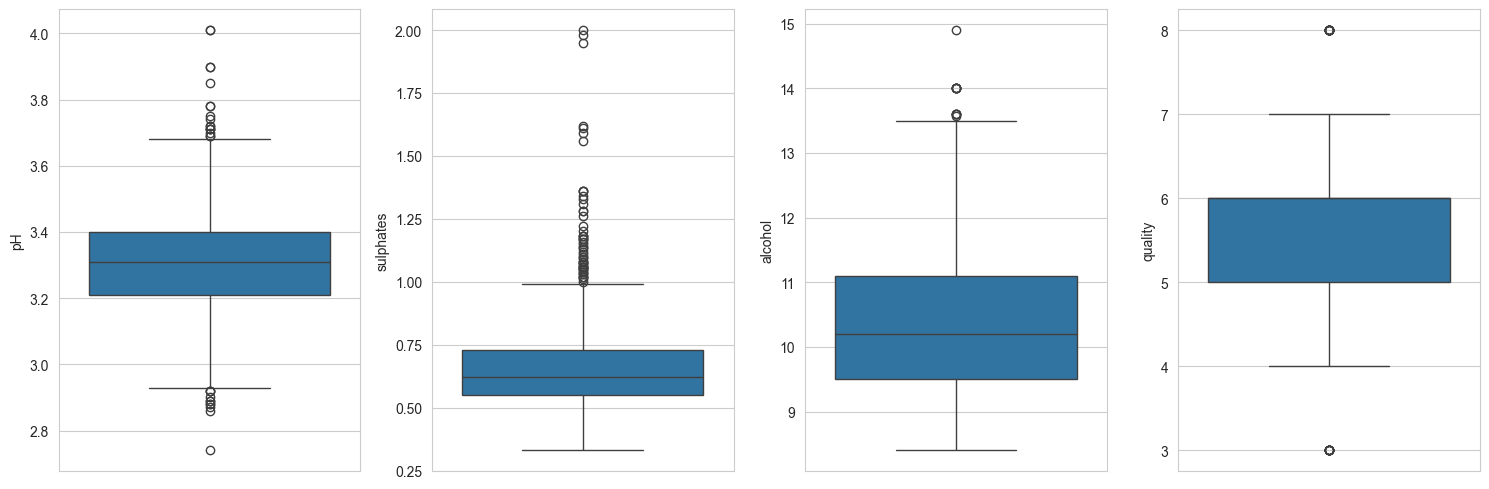

In [37]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="pH")
sns.boxplot(ax=axis[1], data=df, y="sulphates")
sns.boxplot(ax=axis[2], data=df, y="alcohol")
sns.boxplot(ax=axis[3], data=df, y="quality")
plt.tight_layout()
plt.show()

### Observaciones:

> - Buscando en internet podemos obtener los valores máximos normales para estas variables:

| **Variable**             | **Descripción breve**                          | **Valor máximo lógico aproximado** |
|--------------------------|------------------------------------------------|------------------------------------|
| Fixed acidity            | Principalmente ácido tartárico                 | ~16 g/L                            |
| Volatile acidity         | Ácido acético (vinagre)                        | ~1.5 g/L                           |
| Citric acid              | Ácido natural, mejora sabor                    | ~1.0 g/L                           |
| Residual sugar           | Azúcares que no se fermentaron                 | ~65 g/L (en vinos dulces)          |
| Chlorides                | Sales (principalmente cloruro de sodio)        | ~0.2 g/L                           |
| Free sulfur dioxide      | SO₂ libre, protege contra microbios            | ~72 mg/L                           |
| Total sulfur dioxide     | Incluye libre + combinado                      | ~290 mg/L (límite legal EU)       |
| Density                  | Relación masa/volumen (g/cm³)                  | ~1.04                              |
| pH                       | Acidez total (bajo = más ácido)                | ~4.0                               |
| Sulphates                | Conservante y antioxidante (SO₄²⁻)             | ~2.0 g/L                           |
| Alcohol                  | Contenido alcohólico                           | ~15–16 % vol.                      |

>- Observamos que los datos del conjunto están dentro de estos valores menos el de clhorides, aunque lo mantendremos porque no parece que sea un valor demasiado exagerado



### Análisis de valores faltantes

In [38]:
df.isnull().sum().sort_values(ascending=False) / len(df)

fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

#### En este caso no existen valores nulos



## Split de datos (elegimos la variable quality como target)


In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,7.7,0.600,0.06,2.0,0.079,19.0,41.0,0.99697,3.39,0.62,10.1
59,7.3,0.390,0.31,2.4,0.074,9.0,46.0,0.99620,3.41,0.54,9.4
375,11.5,0.540,0.71,4.4,0.124,6.0,15.0,0.99840,3.01,0.83,11.8
1371,7.5,0.580,0.56,3.1,0.153,5.0,14.0,0.99476,3.21,1.03,11.6
1469,7.3,0.980,0.05,2.1,0.061,20.0,49.0,0.99705,3.31,0.55,9.7
...,...,...,...,...,...,...,...,...,...,...,...
164,7.3,0.590,0.26,7.2,0.070,35.0,121.0,0.99810,3.37,0.49,9.4
393,8.4,0.665,0.61,2.0,0.112,13.0,95.0,0.99700,3.16,0.54,9.1
216,8.7,0.625,0.16,2.0,0.101,13.0,49.0,0.99620,3.14,0.57,11.0
1056,8.9,0.480,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están suficientemente normalizados

#### Scaling X_train

In [ ]:
min_max_scaler = MinMaxScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler
num_variables = X_train.columns.tolist()
standard_train_features = min_max_scaler.fit_transform(X_train[num_variables])
X_train_scaled = pd.DataFrame(standard_train_features,
                              index=X_train.index,
                              columns=num_variables)
X_train_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
995,0.267857,0.328767,0.06,0.075342,0.111853,0.253521,0.123675,0.525514,0.511811,0.173653,0.261538
59,0.232143,0.184932,0.31,0.102740,0.103506,0.112676,0.141343,0.466870,0.527559,0.125749,0.153846
375,0.607143,0.287671,0.71,0.239726,0.186978,0.070423,0.031802,0.634425,0.212598,0.299401,0.523077
1371,0.250000,0.315068,0.56,0.150685,0.235392,0.056338,0.028269,0.357197,0.370079,0.419162,0.492308
1469,0.232143,0.589041,0.05,0.082192,0.081803,0.267606,0.151943,0.531607,0.448819,0.131737,0.200000
...,...,...,...,...,...,...,...,...,...,...,...
164,0.232143,0.321918,0.26,0.431507,0.096828,0.478873,0.406360,0.611577,0.496063,0.095808,0.153846
393,0.330357,0.373288,0.61,0.075342,0.166945,0.169014,0.314488,0.527799,0.330709,0.125749,0.107692
216,0.357143,0.345890,0.16,0.075342,0.148581,0.169014,0.151943,0.466870,0.314961,0.143713,0.400000
1056,0.375000,0.246575,0.53,0.212329,0.148581,0.028169,0.014134,0.440975,0.370079,0.155689,0.569231


#### Scaling X_test

In [41]:

X_test_scaled = pd.DataFrame(min_max_scaler.transform(X_test[num_variables]),
                               index=X_test.index,
                               columns=num_variables)
X_test_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
887,0.535714,0.273973,0.38,0.116438,0.090150,0.394366,0.176678,0.434120,0.322835,0.275449,0.569231
717,0.258929,0.232877,0.11,0.116438,0.111853,0.154930,0.151943,0.512567,0.370079,0.143713,0.246154
221,0.241071,0.280822,0.26,0.075342,0.148581,0.211268,0.233216,0.428789,0.322835,0.143713,0.153846
1218,0.312500,0.191781,0.31,0.068493,0.116861,0.098592,0.063604,0.451637,0.393701,0.215569,0.338462
1487,0.116071,0.356164,0.05,0.068493,0.090150,0.112676,0.038869,0.372430,0.614173,0.269461,0.338462
...,...,...,...,...,...,...,...,...,...,...,...
1003,0.187500,0.164384,0.32,0.061644,0.091820,0.042254,0.007067,0.207921,0.488189,0.131737,0.676923
739,0.383929,0.390411,0.00,0.102740,0.126878,0.253521,0.113074,0.680122,0.480315,0.161677,0.138462
645,0.276786,0.356164,0.10,0.349315,0.171953,0.056338,0.017668,0.634425,0.496063,0.215569,0.261538
1300,0.044643,0.359589,0.00,0.085616,0.113523,0.197183,0.077739,0.332826,0.818898,0.167665,0.630769


In [42]:
df_train = pd.concat([X_train_scaled, y_train], axis=1)
df_test = pd.concat([X_test_scaled, y_test], axis=1)

In [43]:
df_train_filtrado.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-filtrado.csv", index=False)
df_test_filtrado.to_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-filtrado.csv", index=False)
